In [139]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint ,ReduceLROnPlateau



In [140]:
image_size=(48,48)
batch_size=32
train_ds=image_dataset_from_directory(
    r"D:\projects\facec detection\Face_detection\image class emotion\train",
    image_size=image_size,
    batch_size=batch_size,
    #color_mode="grayscale",
    shuffle=True,
    validation_split=.2,
    subset="training",
    seed=42
)
val_ds=image_dataset_from_directory(
    r"D:\projects\facec detection\Face_detection\image class emotion\train",
    image_size=image_size,
    batch_size=batch_size,
    #color_mode="grayscale",
    shuffle=False,
    validation_split=.2,
    subset="validation",
    seed=42
)
test_ds=image_dataset_from_directory(
    r"D:\projects\facec detection\Face_detection\image class emotion\test",
    image_size=image_size,
    batch_size=batch_size,
    #color_mode="grayscale",
    shuffle=False
)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.


In [141]:
classes_name=train_ds.class_names
num_classes=len(train_ds.class_names)
print(num_classes)
print(classes_name)

7
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


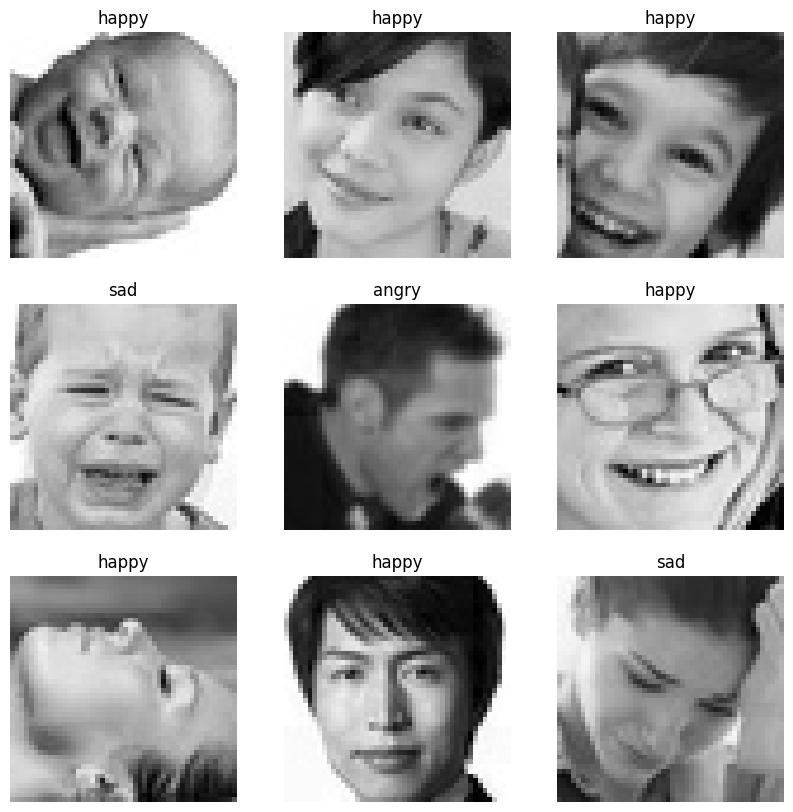

In [142]:
print(classes_name)
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(classes_name[labels[i]])
        plt.axis("off")
plt.show()


In [143]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
])
train_ds=train_ds.map(lambda x, y : (data_augmentation(x,training=True),y))


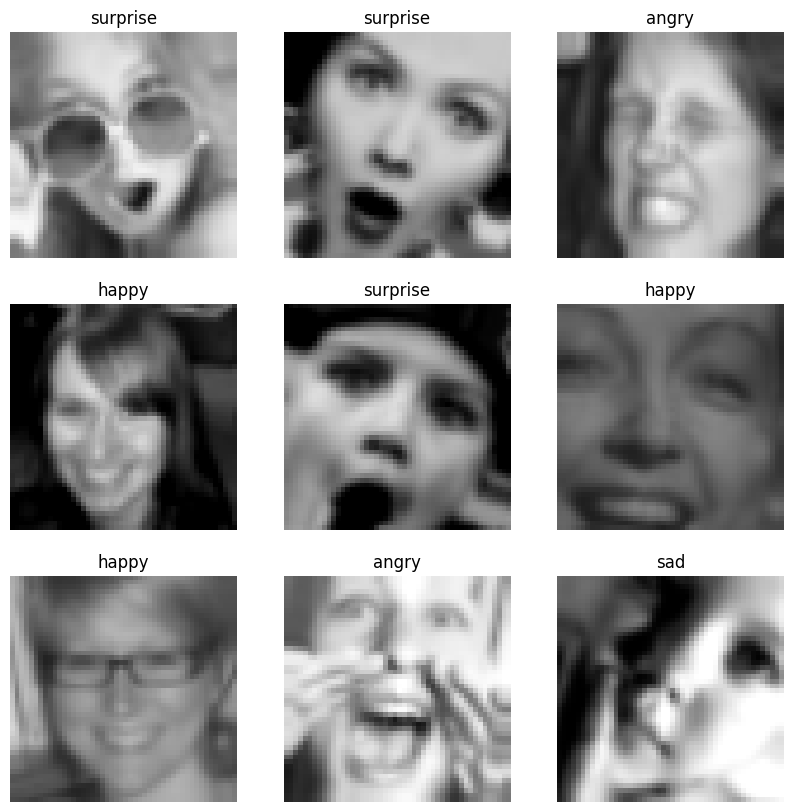

In [ ]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images, training=True)

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.title(classes_name[labels[i]])
        plt.axis("off")


In [145]:
base_model=MobileNetV2(
    input_shape=(48,48,3),
    weights='imagenet',
    include_top=False
)

C:\Users\G15\AppData\Local\Temp\ipykernel_9020\3883785631.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model=MobileNetV2(


In [146]:
base_model.trainable=False

In [147]:
model = tf.keras.Sequential([
    layers.Input(shape=(48,48,3)),
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128,activation='relu'),
    layers.Dense(num_classes,activation='softmax')
])
model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_9 (Lambda)               │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [148]:
base_model.trainable=True
for layer in base_model.layers[:-20]:
    layer.trainable=False

In [149]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=.00001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
              )

In [150]:
early_stopping=EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
model_checkpoint=ModelCheckpoint(
    "best_emotion_model_M4.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
call_backs_list=[early_stopping,model_checkpoint,reduce_lr]

In [151]:
history1=model.fit(train_ds,
                   validation_data=val_ds,
                   epochs=60,
                   callbacks=call_backs_list,
                   verbose=1)

Epoch 1/60
717/718 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.1767 - loss: 2.1915
Epoch 1: val_loss improved from None to 2.50014, saving model to best_emotion_model_M4.keras

Epoch 1: finished saving model to best_emotion_model_M4.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.2115 - loss: 2.0540 - val_accuracy: 0.1312 - val_loss: 2.5001 - learning_rate: 1.0000e-05
Epoch 2/60
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2776 - loss: 1.8363
Epoch 2: val_loss improved from 2.50014 to 2.15546, saving model to best_emotion_model_M4.keras

Epoch 2: finished saving model to best_emotion_model_M4.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 35s 48ms/step - accuracy: 0.2839 - loss: 1.8189 - val_accuracy: 0.2224 - val_loss: 2.1555 - learning_rate: 1.0000e-05
Epoch 3/60
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3120 - loss: 1.7489
Epoch 3: val_loss improved from 2.15546 to 1.88703, saving model to best_emotion_model_M4.keras

Epoch 3: finished saving model to

In [152]:
test_loss,test_acc=model.evaluate(test_ds)
print("Test accuracy:",test_acc,"loss accuracy:",test_loss)


225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.4780 - loss: 1.4106
Test accuracy: 0.4779883027076721 loss accuracy: 1.4106416702270508


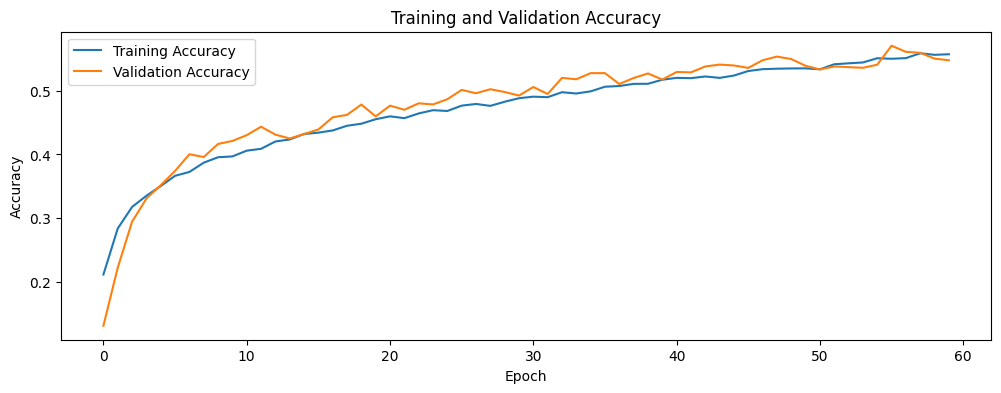

In [153]:
plt.figure(figsize=(12, 4))
plt.plot(history1.history['accuracy'], label='Training Accuracy')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [154]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
model=load_model("best_emotion_model_M4.keras",custom_objects={'preprocess_input': preprocess_input})

In [155]:
early_stopping=EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
model_checkpoint=ModelCheckpoint(
    "best_emotion_model_M5.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
call_backs_list=[early_stopping,model_checkpoint,reduce_lr]

In [156]:
history2=model.fit(train_ds,
                   validation_data=val_ds,
                   epochs=40,
                   callbacks=call_backs_list,
                   verbose=1)

Epoch 1/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5631 - loss: 1.1819
Epoch 1: val_loss improved from None to 1.20945, saving model to best_emotion_model_M5.keras

Epoch 1: finished saving model to best_emotion_model_M5.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.5571 - loss: 1.1859 - val_accuracy: 0.5644 - val_loss: 1.2094 - learning_rate: 1.0000e-05
Epoch 2/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5559 - loss: 1.1871
Epoch 2: val_loss did not improve from 1.20945
718/718 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step - accuracy: 0.5586 - loss: 1.1842 - val_accuracy: 0.5523 - val_loss: 1.2347 - learning_rate: 1.0000e-05
Epoch 3/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5554 - loss: 1.1843
Epoch 3: val_loss improved from 1.20945 to 1.20417, saving model to best_emotion_model_M5.keras

Epoch 3: finished saving model to best_emotion_model_M5.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step - accuracy: 0.5554 - loss: 1.1836 - val_

In [157]:
model.evaluate(test_ds)

225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.4861 - loss: 1.4180


[1.418031930923462, 0.4860685467720032]

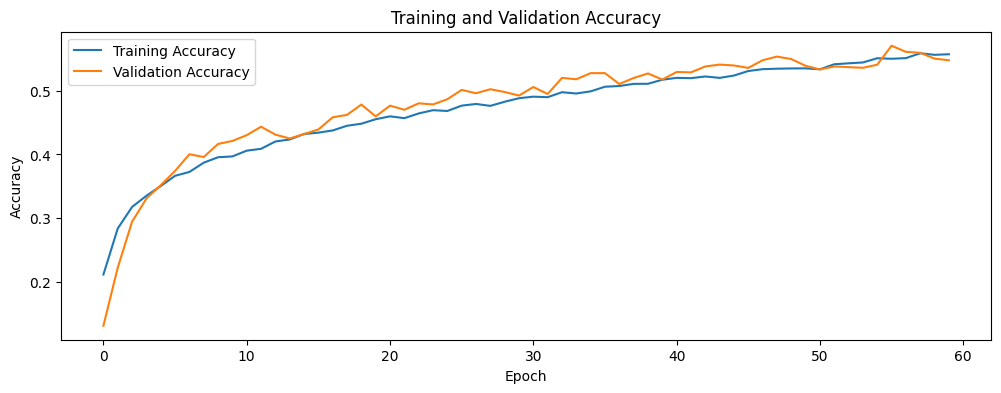

In [158]:
plt.figure(figsize=(12, 4))
plt.plot(history1.history['accuracy'], label='Training Accuracy')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [159]:
model=load_model("best_emotion_model_M5.keras",custom_objects={'preprocess_input': preprocess_input})

In [160]:
early_stopping=EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
model_checkpoint=ModelCheckpoint(
    "best_emotion_model_M6.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
call_backs_list=[early_stopping,model_checkpoint,reduce_lr]

In [161]:
history2=model.fit(train_ds,
                   validation_data=val_ds,
                   epochs=50,
                   callbacks=call_backs_list,
                   verbose=1)

Epoch 1/50
717/718 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5684 - loss: 1.1477
Epoch 1: val_loss improved from None to 1.13908, saving model to best_emotion_model_M6.keras

Epoch 1: finished saving model to best_emotion_model_M6.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.5694 - loss: 1.1478 - val_accuracy: 0.5884 - val_loss: 1.1391 - learning_rate: 1.0000e-05
Epoch 2/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5732 - loss: 1.1402
Epoch 2: val_loss did not improve from 1.13908
718/718 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.5753 - loss: 1.1391 - val_accuracy: 0.5818 - val_loss: 1.1669 - learning_rate: 1.0000e-05
Epoch 3/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5682 - loss: 1.1378
Epoch 3: val_loss did not improve from 1.13908
718/718 ━━━━━━━━━━━━━━━━━━━━ 35s 48ms/step - accuracy: 0.5706 - loss: 1.1362 - val_accuracy: 0.5651 - val_loss: 1.2047 - learning_rate: 1.0000e-05
Epoch 4/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/

In [162]:
model.evaluate(test_ds)

225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.4937 - loss: 1.4690


[1.4690475463867188, 0.4937308430671692]

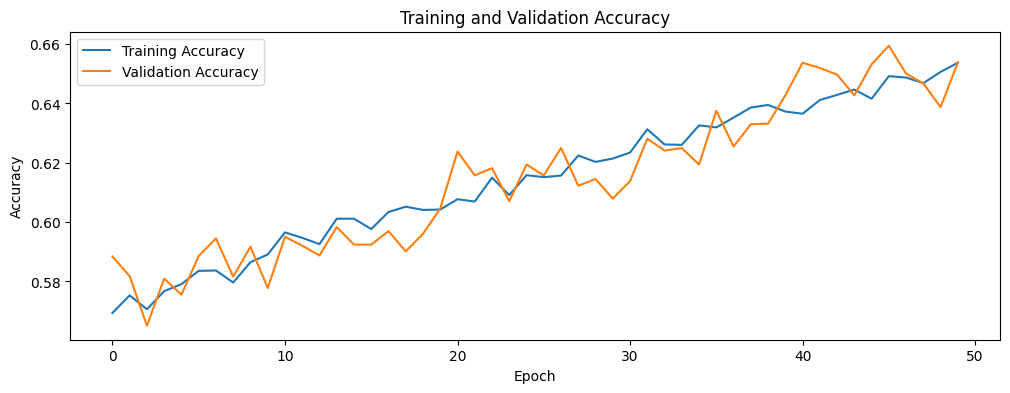

In [165]:
plt.figure(figsize=(12, 4))
plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()